In [1]:
import pandas as pd
df = pd.read_csv("pakistan_job_market_dataset.csv")

In [2]:
df.shape

(10500, 13)

In [3]:
#data cleaning pipeline
def clean_data(df):
    #droping column with 50% missing value
    threshold= len(df)*0.5
    df = df.dropna(thresh=threshold,axis=1)

    #imputing numerical values with median
    #median is better cuz its not affected by outliers
    for col in df.select_dtypes(include='number').columns:
        df[col] = df[col].fillna(df[col].median())


    #imputes categorical columns with mode,
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    #duplicates drop
    df = df.drop_duplicates()

    #converts all date columns to proper datetime objects
    df['Posted Date'] = pd.to_datetime(df['Posted Date'])
    df['Application Deadline'] = pd.to_datetime(df['Application Deadline'], errors='coerce')

    #creates 2 derived features that add analytical value
    df['Posting Year'] = df['Posted Date'].dt.year
    df['is_Remote'] = (df['Job Type']=='Remote').astype(int)

    
    return df

In [4]:
df = clean_data(df)
print(df.shape)

(10500, 15)


In [ ]:
#10 publication-quality visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#seaborn theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

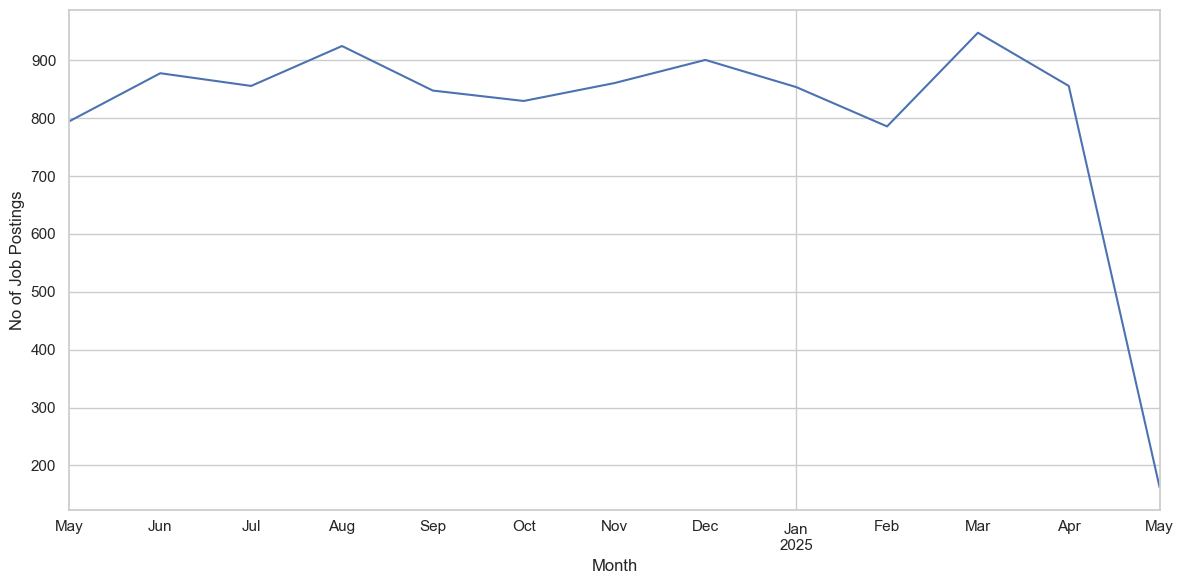

In [6]:
#Time series chart
monthly_jobs = df.set_index('Posted Date').resample("ME").size()
monthly_jobs.plot()
plt.xlabel("Month")
plt.ylabel("No of Job Postings")
plt.tight_layout()
plt.show()



Job postings in Pakistan remained consistently high between May 2024 and April 2025, ranging from 795 to 948 per month. March 2025 recorded the highest number of postings at 948, suggesting a peak hiring season in early 2025.


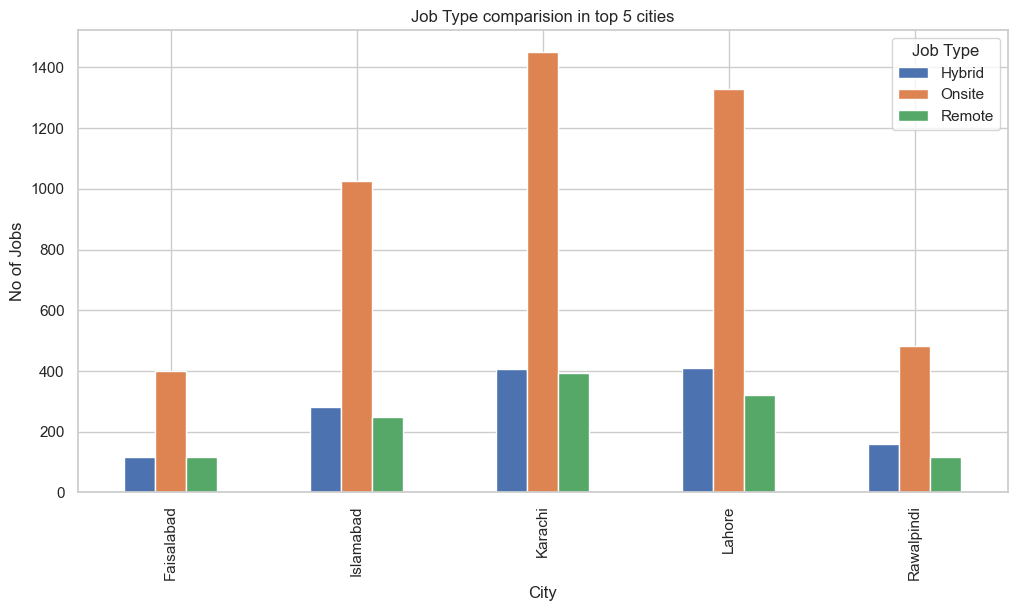

In [7]:
#rouped bar chart (comparison across categories)

#top 5 cities by job postings for cleaner visualization
df['City']= df['City'].str.title()
top5_cities = df['City'].value_counts().head(5).index
df_top5 = df[df['City'].isin(top5_cities)]

grouped = df_top5.groupby(['City','Job Type']).size().unstack()
grouped.plot(kind='bar')
plt.title("Job Type comparision in top 5 cities")
plt.xlabel("City")
plt.ylabel("No of Jobs")
plt.legend(title='Job Type')
plt.show()

Onsite jobs dominate all top 5 cities, with Karachi and Lahore having the highest overall job postings. Remote work opportunities are surprisingly similar across all cities, suggesting remote hiring is not concentrated in any specific city.

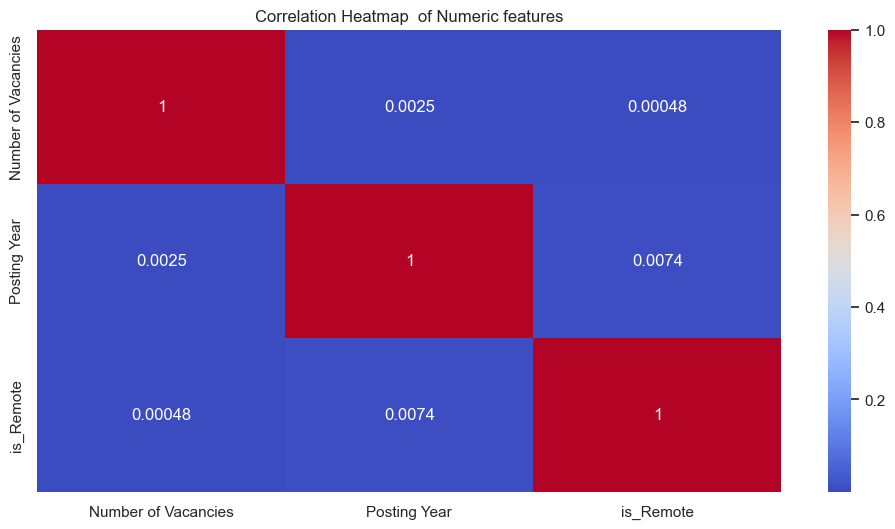

In [8]:
#heatmap (correlation matrix)
sns.heatmap(df.select_dtypes(include='number').corr(), annot= True,cmap="coolwarm")
plt.title("Correlation Heatmap  of Numeric features")
plt.show()

All three numeric features show near-zero correlation with each other, confirming they are independent variables. This suggests that number of vacancies, posting year, and remote status have no linear relationship in Pakistan's job market dataset.


<Axes: xlabel='City'>

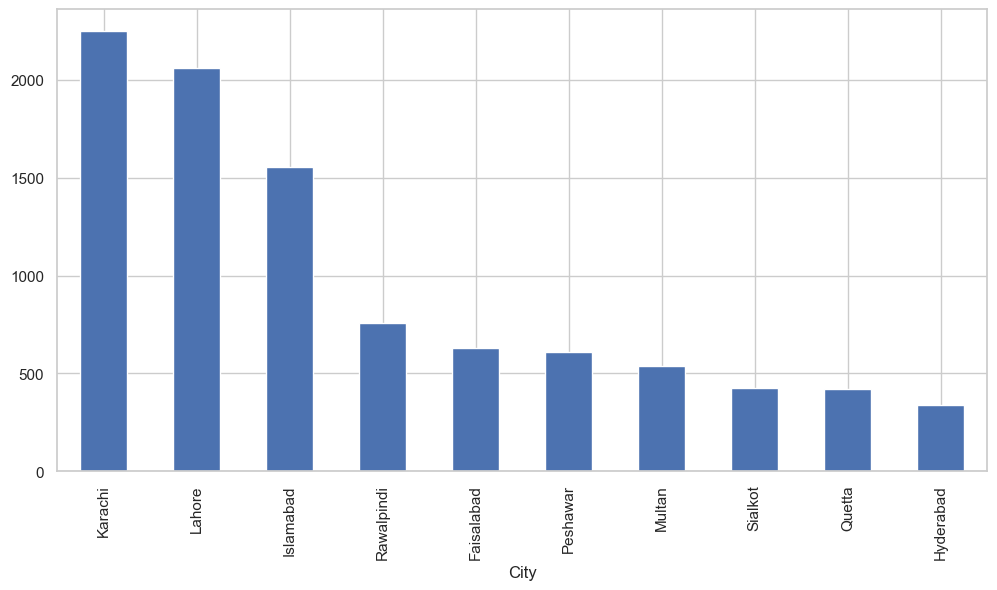

In [9]:
# choropleth or regional bar chart (by province/city)

df['City'].value_counts().head(10).plot(kind='bar')

Karachi dominates Pakistan's job market with over 2100 postings, followed by Lahore and Islamabad.


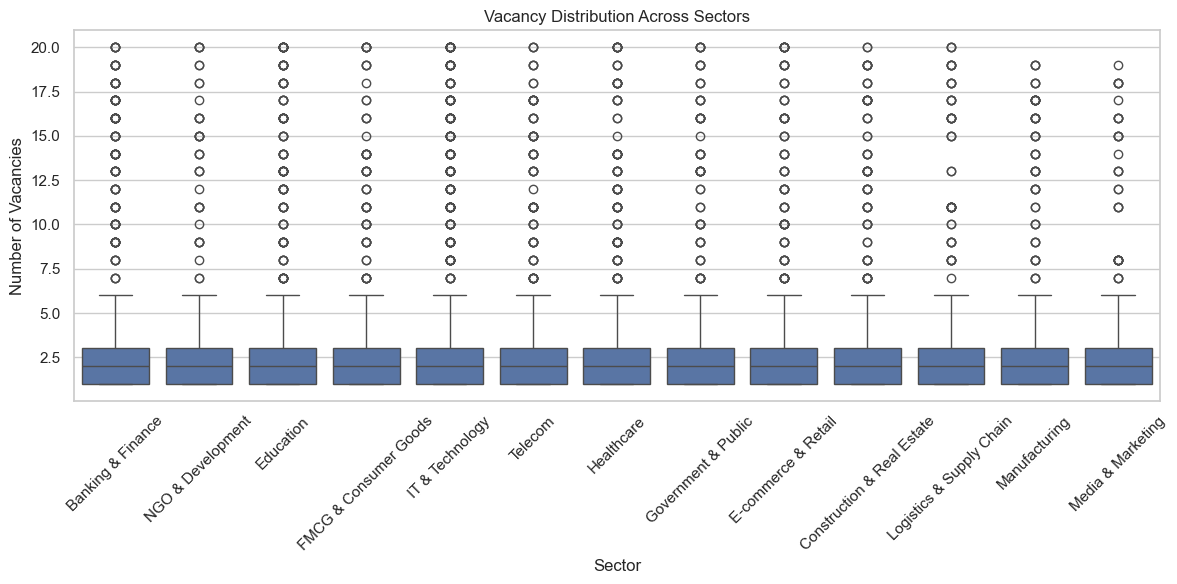

In [10]:
# box plot (distribution comparison)

sns.boxplot(x='Sector', y='Number of Vacancies', data=df)
plt.title('Vacancy Distribution Across Sectors')
plt.xlabel('Sector')
plt.ylabel('Number of Vacancies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vacancy distribution is remarkably consistent across all sectors in Pakistan's job market, with most postings offering 1-3 positions regardless of industry. The presence of outliers up to 20 vacancies across every sector suggests bulk hiring happens sporadically in all industries

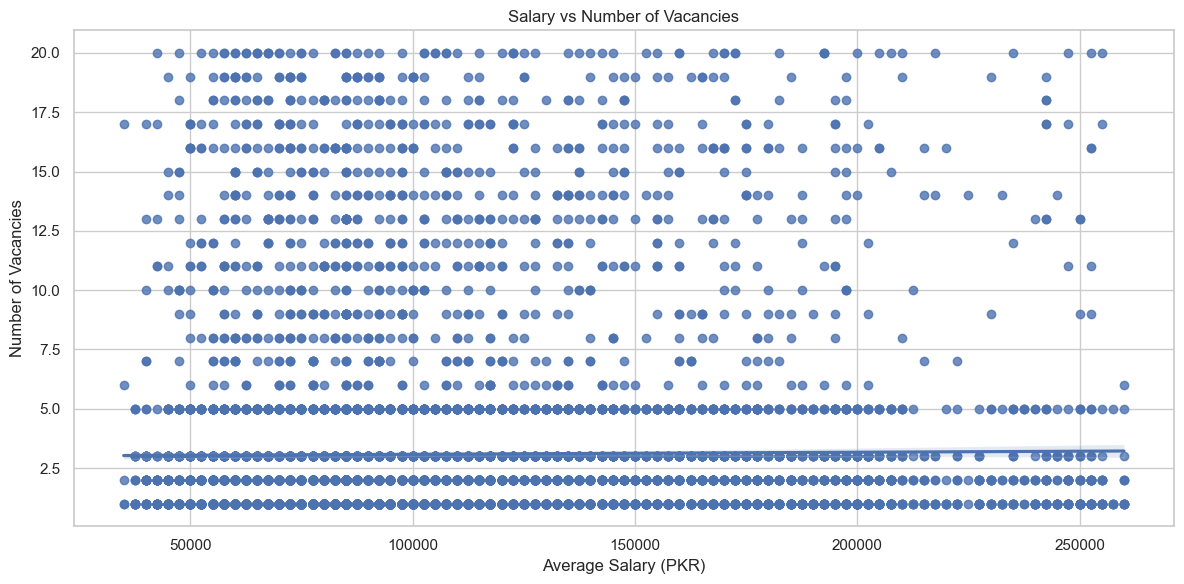

In [11]:
# scatter plot with a regression line
df['Salary Avg'] = df['Salary Range (PKR)'].str.replace(',', '').str.split(' - ').apply(lambda x: (int(x[0]) + int(x[1])) / 2 if isinstance(x, list) and len(x) == 2 else None)
sns.regplot(x='Salary Avg',y='Number of Vacancies',data=df)
plt.title('Salary vs Number of Vacancies')
plt.xlabel('Average Salary (PKR)')
plt.ylabel('Number of Vacancies')
plt.tight_layout()
plt.show()

There is no meaningful relationship between average salary and number of vacancies in Pakistan's job market. Companies offering high salaries are just as likely to have 1 vacancy as companies offering low salaries.

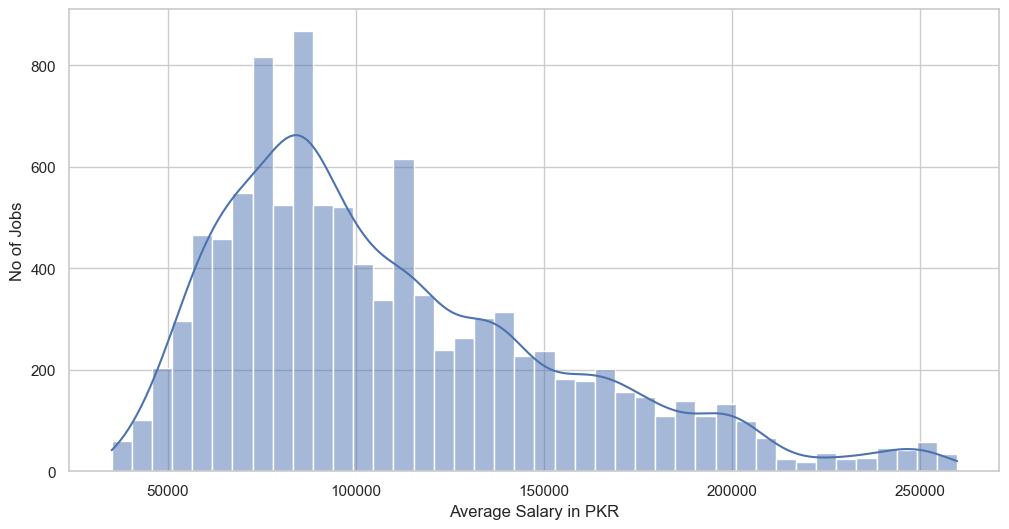

In [12]:
#histogram with KDE curve
sns.histplot(df['Salary Avg'].dropna(),kde=True)
plt.xlabel("Average Salary in PKR")
plt.ylabel("No of Jobs")
plt.show()

Most job postings in Pakistan offer salaries between 70,000 and 100,000 PKR per month, with the distribution heavily skewed to the right. High salary positions above 200,000 PKR are rare, reflecting the general wage structure of Pakistan's formal job market.

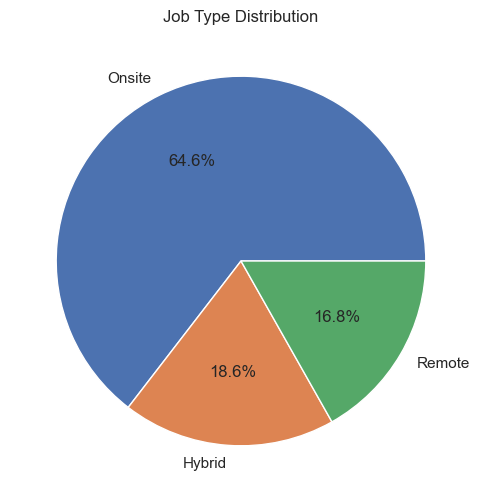

In [13]:
# pie chart (for proportions — use sparingly).
job_types = df['Job Type'].value_counts()
plt.pie(job_types,labels=job_types.index, autopct='%1.1f%%')
plt.title("Job Type Distribution")
plt.show()

Onsite jobs dominate Pakistan's job market at 64.6%, with Hybrid and Remote roles making up only 35% combined.

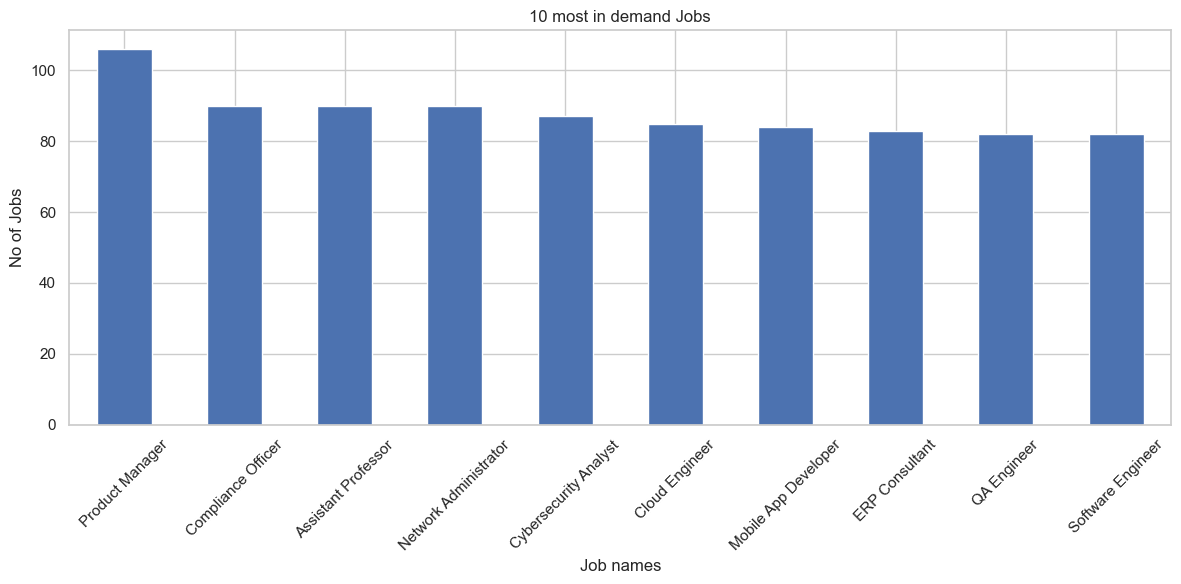

In [14]:
#Bar chart of top 10 most in demand job titles
df['Job Title'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Job names")
plt.ylabel("No of Jobs")
plt.title("10 most in demand Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product Manager is the most in-demand job title in Pakistan with over 105 postings, followed closely by Compliance Officer, Assistant Professor and Network Administrator

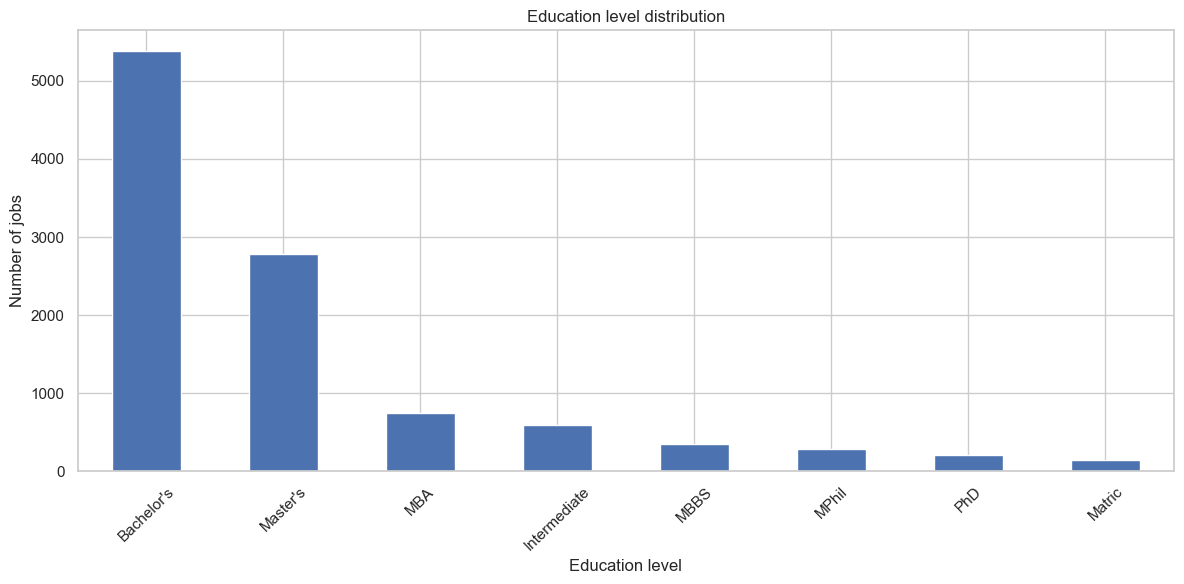

In [15]:
#education level disttibutuin
df['Education Level'].value_counts().plot(kind='bar')
plt.title("Education level distribution")
plt.xlabel("Education level")
plt.ylabel("Number of jobs")
plt.xticks(rotation=44)
plt.tight_layout()
plt.show()

 Bachelor's degree dominates Pakistan's job market requirements with over 5000 postings, making it the minimum standard for most employers

In [16]:
#600 words story


Pakistan Job Market Story
This analysis explores 10,500 job postings from Pakistan's job market between May 2024 and April 2025. the data tells an interesting story about where jobs are, what they pay, and what employers actually want. we looked at 10 different charts to understand this market properly and here is what we found.
First thing that stands out is geography. Karachi dominates with over 2100 job postings, followed by Lahore and Islamabad. these three cities alone covers majority of Pakistani job market. if you are a job seeker outside these cities, your options are significantly limited. Rawalpindi and Faisalabad come fourth and fifth but with much fewer postings around 759 and 629. this concentration of opportunity in three cities is a major structural problem for Pakistani economy. talented people in smaller cities like Quetta, Sukkur or Abbottabad have very few options without relocating.
Looking at monthly trends, job postings stayed pretty consistent throughout the year ranging from 795 to 948 per month. there was no major crash or boom which suggests Pakistan's job market is stable but not growing explosively. March 2025 had the highest activity at 948 postings which might indicate a seasonal hiring push before the financial year ends. May 2025 shows only 162 postings but that is because the dataset ends mid May so it is not a real drop.
when we look at job types the results are quite clear. 64.6% of all jobs are onsite, with hybrid at 18.6% and remote only 16.8%. Pakistan is still very much an onsite culture. compare this to global trends where remote work has exploded since 2020 and you can see Pakistan's corporate sector is behind the curve. this is a big problem for talented people in smaller cities who cannot relocate to Karachi or Lahore. only 16.8% remote opportunities means geography is still a huge barrier for Pakistani job seekers.
When we compare job types across top 5 cities the pattern is same everywhere. Karachi, Lahore, Islamabad, Rawalpindi and Faisalabad all have onsite as the dominant job type. no single city is significantly more remote friendly than others. so remote work culture is equally low across all major cities which is surprising.
Salary analysis reveals that most jobs in Pakistan pay between 70,000 to 100,000 PKR per month. the distribution is right skewed meaning a small number of high paying jobs exist but majority of postings offer moderate salaries. very few jobs cross 200,000 PKR. interestingly salary has almost no relationship with number of vacancies meaning companies dont offer more positions just because they pay more. a company paying 250,000 PKR is just as likely to have 1 vacancy as a company paying 50,000 PKR.
Vacancy distribution across sectors is also very similar everywhere. most job postings across all sectors offer 1 to 3 positions. construction and real estate sector tends to hire slightly more people per posting but the difference is not huge. this tells us that bulk hiring is rare in Pakistan's formal job market.
Education requirements show that bachelors degree is basically the minimum requirement for formal employment in Pakistan. over 5000 postings require bachelors while masters comes second at 2800. PhD and MPhil roles are very niche mostly found in academia and research institutions. intermediate and matric qualifications have very few postings which means without a degree your options in formal sector are very limited.
Finally the most in demand job titles include product manager, compliance officer, cloud engineer and software engineer. this shows that Pakistan's market is slowly shifting toward tech and management roles which is a positive sign for the future. overall Pakistan's job market is stable, city concentrated, onsite heavy, and bachelor dominated. the opportunities are there but mostly in three cities and mostly requiring you to show up physically every day